
# Notebook 4 - Modelling and Double Machine Learning + Heterogeneity and Sensitivity

This notebook implements the **full modelling stage** of the project along with heterogeneity checks and the sensitivity analysis.

## Research question
**What is the causal effect of in-hospital insulin prescription on 30-day readmission for diabetic patients?**

## What this notebook does:
This notebook estimates the causal effect of in-hospital insulin prescription on 30-day readmission for diabetic patients and presents the key results of this analysis. It builds directly on the DAG analysis developed in Notebook 3, using the core pre-treatment covariates we carefully selected.

The notebook is organized into five parts:

**Part 1 - Benchmark Models**

Before applying DML, we establish a set of conventional 
econometric benchmarks. We start with a naive linear 
probability model (Y ~ D) that ignores confounding entirely, 
then add the full covariate set (Y ~ D + X), and finally 
apply Double Post-Lasso which performs sparse variable 
selection before estimating the treatment effect. These 
benchmarks serve two purposes: they show what a naive 
analysis would conclude, and they provide a reference point 
against which to evaluate the DML estimates.

**Part 2 - Double Machine Learning Estimation**

We estimate the causal effect of insulin on readmission using Double Machine Learning. This requires two steps. 
- First, we select the best nuisance learners by evaluating the ML models that predict treatment and outcome from covariates through nested cross-validation, comparing Logistic Regression, Random Forest, and Gradient Boosting.
- Second, we estimate the treatment effect using three DML estimators: DML-PLR (partially linear regression), DML-IRM ATE (average treatment effect), and DML-IRM ATTE (average treatment effect on the treated). A forest plot is then used to compare all estimates (benchmarks and DML).

**Part 3 - Heterogeneous Treatment Effects**

We test whether the treatment effect varies across pre-specified patient subgroups motivated by the EDA and the research question: age (65+), prior hospitalisation history, gender, weight observed (monitoring intensity) and primary diabetes diagnosis. For each subgroup we re-estimate the DML-IRM ATE on the subgroup sample and compare estimates across groups.

**Part 4 - Sensitivity Analysis**

We assess the robustness of the main finding along three dimensions. 
- First, we test alternative treatment definitions (steady insulin only and escalating insulin only) to check whether results are sensitive to how insulin is coded. We also use this opportunity to run a short extension where we test the causal effect of an alternative medication administered to diabetic patients in the data, namely metformin
- Second, we re-run the main DML-IRM with an extended covariate set that adds the timing-ambiguous variables identified in Notebook 3.
- Third, we run a placebo check by randomly permuting treatment assignment. Essentially if the 
estimator is working correctly, the permuted treatment should produce an effect near zero.

**Part 5 - Conclusion, Summary of Results, and Limitations**

We close the notebook with a summary of the main findings across all estimators and subgroups, a discussion of what the results mean for the research question, and assessment of the limitations of the analysis.


Please note that both the **outcome** and the **treatment** are binary in our models and so we focus on **predicted probabilities**. We will judge the final estimates by their **effect estimates and uncertainty** and not by prediction accuracy.


## Part 0 - Preliminary Steps

### 0.1. Environment setup

In [1]:

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedShuffleSplit,
    GridSearchCV,
    RandomizedSearchCV,
    cross_validate,
)
from sklearn.metrics import (
    mean_squared_error,
    log_loss,
    roc_auc_score,
    accuracy_score,
)
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.linear_model import LassoCV, LogisticRegression, LogisticRegressionCV, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

import doubleml as dml
from doubleml import DoubleMLData

project_folder_path = Path("..")
data_folder_path = project_folder_path / "data"
figures_folder_path = project_folder_path / "figures"

data_path = data_folder_path / "analysis_data.csv"

seed = 42
np.random.seed(seed)

In [2]:
# some configurations

cv_outer_folds = 3
cv_inner_folds = 3
search_iterations = 5


### 0.2. Load the final dataset

In [3]:

df = pd.read_csv(data_path)
analysis_df = df.copy()

print(f"Shape: {analysis_df.shape}")
analysis_df.head()


Shape: (67315, 75)


,female,age_numeric,weight_observed,A1C_tested,A1C_abnormal,glu_tested,glu_abnormal,med_change,any_non_insulin_meds,primary_diag_diabetes,...,specialty_Emergency/Trauma,specialty_Cardiology,specialty_Surgery-General,specialty_Other,specialty_Unknown,readmitted_30,insulin_any,insulin_steady_only,insulin_up_only,treatment_multivalued
0,1,85,0,0,0,0,0,1,1,0,...,0,0,0,0,1,0,1,1,0,3
1,1,95,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,1,1,0,3
2,0,45,0,0,0,0,0,1,1,0,...,0,0,0,0,1,0,1,1,0,3
3,1,45,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,1,1,0,2
4,0,55,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,1,0,2



### 0.3. Define `Y`, `D`, and the final control set `X`


We define here the outcome variable Y, the treatment variable D, and the core pre-treatment covariate set X identified through the DAG analysis.

- **Y** = 'readmitted_30' - 1 if readmitted within 30 days
- **D** = 'insulin_any' - 1 if any insulin received during stay
- **X** = 36 pre-treatment covariates from the DAG core set

The timing-ambiguous variables identified in Notebook 3 
(within-stay severity signals, lab results, medication 
management) are excluded from the main specification and 
will be added only in the sensitivity analysis in Part 4.

In [ ]:
# use ANY dosage of insulin as treatment variable
outcome_var = "readmitted_30"
treatment_var = "insulin_any"

# X columns that are selected during the DAG part
# these columns are "before" the treatment and the outcome is assigned (time-wise)

X_columns = [
    # demographics and fixed characteristics
    "female", "age_numeric",
    "race_AfricanAmerican", "race_Hispanic", "race_Asian", "race_Other", "race_Unknown",

    # admission context, fixed at or before admission
    "admission_type_Urgent", "admission_type_Elective", "admission_type_Other",
    "admission_source_Referral", "admission_source_Transfer", "admission_source_Other",

    # prior hospital visits
    "number_outpatient", "number_emergency", "number_inpatient",

    # payer and provider context
    "payer_HM", "payer_BC", "payer_Other", "payer_Unknown",
    "specialty_Family/GeneralPractice", "specialty_Emergency/Trauma",
    "specialty_Cardiology", "specialty_Surgery-General",
    "specialty_Other", "specialty_Unknown",

    # diagnosis context
    "primary_diag_diabetes", "diag_circulatory", "diag_respiratory",
    "diag_digestive", "diag_diabetes", "diag_injury",
    "diag_musculoskeletal", "diag_genitourinary",
    "diag_neoplasms", "diag_other"
]

print(f"Number of X columns: {len(X_columns)}")

Y = analysis_df[outcome_var]
D = analysis_df[treatment_var]
X = analysis_df[X_columns]
print(f"Treatment rate: {D.mean():.1%}")
print(f"Outcome rate: {Y.mean():.1%}")

Number of X columns: 36


Treatment rate: 52.1%
Outcome rate: 9.0%


As sanity checks, we remember that the share of patients who receive insulin is 52%, while the share of patients readmitted within 30 days is 9% 


### 0.4. Define `numeric` and `binary` features.


In [5]:

binary_features = [
    c for c in X_columns
    if set(pd.Series(X[c]).dropna().unique()).issubset({0, 1})
]

numeric_features = [c for c in X_columns if c not in binary_features]

print(f"\nBinary controls: {len(binary_features)}")
print(f"Numeric controls: {len(numeric_features)}")



Binary controls: 32
Numeric controls: 4



### 0.5. Preprocessing pipelines

Because the final control set mixes **numeric** and **binary** variables, we build preprocessing explicitly.

The `linear_preprocessor` imputes missing numeric values with the median and standardizes them, because linear / penalized models are sensitive to scale. Binary features are only imputed, as scaling 0/1 indicators is not needed.

The `tree_preprocessor` also imputes missing values, but does not scale features, because tree-based models are invariant to rescaling of the inputs.

We then fit a copy of the linear preprocessor once to recover the final transformed feature names.

Besides, we do preprocessing inside a `Pipeline` (so it happens inside cross-validation), which avoids leakage.

In [6]:
# column positions instead of column names
numeric_idx = [X.columns.get_loc(col) for col in numeric_features]
binary_idx = [X.columns.get_loc(col) for col in binary_features]

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_idx,
        ),
        (
            "bin",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
            ]),
            binary_idx,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_idx,
        ),
        (
            "bin",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
            ]),
            binary_idx,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# fitting to recover transformed feature names
feature_name_probe = clone(linear_preprocessor).fit(X)
transformed_feature_names = feature_name_probe.get_feature_names_out()

print(f"Number of transformed features: {len(transformed_feature_names)}")
print(transformed_feature_names)

Number of transformed features: 36
['age_numeric' 'number_outpatient' 'number_emergency' 'number_inpatient'
 'female' 'race_AfricanAmerican' 'race_Hispanic' 'race_Asian' 'race_Other'
 'race_Unknown' 'admission_type_Urgent' 'admission_type_Elective'
 'admission_type_Other' 'admission_source_Referral'
 'admission_source_Transfer' 'admission_source_Other' 'payer_HM'
 'payer_BC' 'payer_Other' 'payer_Unknown'
 'specialty_Family/GeneralPractice' 'specialty_Emergency/Trauma'
 'specialty_Cardiology' 'specialty_Surgery-General' 'specialty_Other'
 'specialty_Unknown' 'primary_diag_diabetes' 'diag_circulatory'
 'diag_respiratory' 'diag_digestive' 'diag_diabetes' 'diag_injury'
 'diag_musculoskeletal' 'diag_genitourinary' 'diag_neoplasms' 'diag_other']



## Part 1 - Benchmark econometric models

We start with two intentionally simple benchmarks:

1. **Naive LPM**: `Y ~ D`
2. **Adjusted LPM**: `Y ~ D + X`

We use a linear probability model here since:
- it keeps the treatment effect on an interpretable probability scale,
- it is easy to compare with DML estimates that are also interpreted as changes in the outcome probability,
- it serves as a good transparent benchmark.

### 1.1. Naive Linear Benchmark Models

In [7]:
def ci95(est, se):
    z = 1.96
    return est - z * se, est + z * se

# Naive LPM: Y ~ D
X_naive = sm.add_constant(D)
naive_lpm = sm.OLS(Y, X_naive).fit(cov_type="HC3")

# Adjusted LPM: Y ~ D + X
X_adjusted = sm.add_constant(pd.concat([D, X], axis=1))
adjusted_lpm = sm.OLS(Y, X_adjusted).fit(cov_type="HC3")

print("Naive LPM:")
print(f"  Coefficient: {naive_lpm.params[treatment_var]:.4f}")
print(f"  Std error: {naive_lpm.bse[treatment_var]:.4f}")
print(f"  p-value: {naive_lpm.pvalues[treatment_var]:.4f}")
print(f"  95% CI: [{naive_lpm.conf_int().loc[treatment_var, 0]:.4f}, {naive_lpm.conf_int().loc[treatment_var, 1]:.4f}]")

print("\nAdjusted LPM:")
print(f"  Coefficient: {adjusted_lpm.params[treatment_var]:.4f}")
print(f"  Std error: {adjusted_lpm.bse[treatment_var]:.4f}")
print(f"  p-value: {adjusted_lpm.pvalues[treatment_var]:.4f}")
print(f"  95% CI: [{adjusted_lpm.conf_int().loc[treatment_var, 0]:.4f}, {adjusted_lpm.conf_int().loc[treatment_var, 1]:.4f}]")


Naive LPM:
  Coefficient: 0.0136
  Std error: 0.0022
  p-value: 0.0000
  95% CI: [0.0093, 0.0179]

Adjusted LPM:
  Coefficient: 0.0145
  Std error: 0.0023
  p-value: 0.0000
  95% CI: [0.0101, 0.0189]


### **Interpretation**

Both the naive and adjusted LPM estimates are positive 
and statistically significant at the 1% level.

The **naive LPM** (Y ~ D only) estimates that insulin patients have a **1.36 percentage point higher** probability of 30-day readmission compared to non-insulin patients. This is a raw association with no adjustment for confounding. It captures both the causal effect of insulin and the fact that sicker patients receive insulin and are more likely to be readmitted regardless.

The **adjusted LPM** (Y ~ D + X) estimates a slightly larger effect of **1.45 percentage points**. Adding the full pre-treatment covariate set marginally increases the estimated effect. This is counterintuitive at first glance since we would expect the confounding to drive the naive estimate upward.

Both estimates suggest a positive association between insulin and readmission. However, neither can be given a causal interpretation as the LPM does not account for the non-linear confounding effects. 


### **Identifying strongest outcome predictors**

We fit a linear probability model (LPM) on the preprocessed covariates and compute standardized coefficients to compare variable importance on a common scale. The pipeline first applies the linear preprocessor, then estimates a linear regression for Y.

After fitting, we transform X. We multiply each coefficient by the standard deviation of its transformed feature, so the coefficients reflect the change in the prediction from a one-SD change in X.

The resulting ranking is only for interpretation, not causal identification, and helps show which covariates are most strongly associated with the outcome. The table and bar chart display the 15 largest coefficients in absolute value.



,standardized_coef
number_inpatient,0.027612
age_numeric,0.011880
number_emergency,0.005210
payer_Unknown,0.005114
specialty_Cardiology,-0.004785
diag_injury,0.004751
diag_circulatory,0.004267
diag_neoplasms,0.003890
payer_BC,-0.003578
primary_diag_diabetes,0.003254


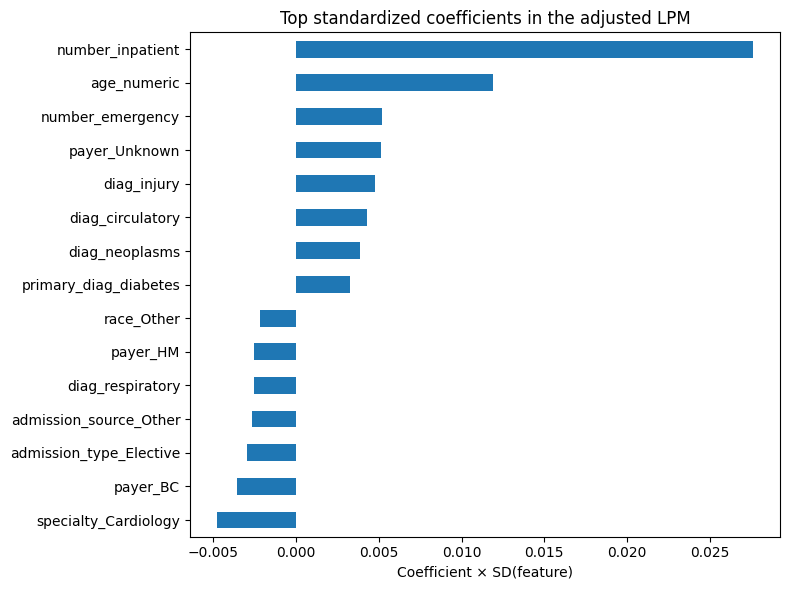

In [8]:

standardized_lpm_pipe = Pipeline([
    ("preprocess", clone(linear_preprocessor)),
    ("model", LinearRegression()),
])

standardized_lpm_pipe.fit(X, Y)
X_transformed = standardized_lpm_pipe.named_steps["preprocess"].transform(X)
coef_values = standardized_lpm_pipe.named_steps["model"].coef_

std_coef = pd.Series(
    coef_values * X_transformed.std(axis=0),
    index=standardized_lpm_pipe.named_steps["preprocess"].get_feature_names_out(),
).sort_values(key=np.abs, ascending=False)

std_coef_df = std_coef.rename("standardized_coef").to_frame()
display(std_coef_df.head(15))

plt.figure(figsize=(8, 6))
std_coef.head(15).sort_values().plot(kind="barh")
plt.title("Top standardized coefficients in the adjusted LPM")
plt.xlabel("Coefficient × SD(feature)")
plt.tight_layout()



### 1.2. Double Post-Lasso benchmark

Let's remember the key steps in Double Post-Lasso. We follow three steps:
1) _Run Lasso of Y on X_: Lasso will regress the outcome (readmission) on all covariates and shrinks the weak coefficients to exactly 0. We then only keep the variables with non-zero coefficients (which are the best predictors of readmission).
2) _Run Lasso of D on X_: Lasso will regress the treatment (insulin) on all covariates and again keep the non-zero ones (best predictors of insulin assignment).
3) _Run OLS of Y on D and the union of selected variables_: we take the union of variables selected in the previous steps and run a standard unpenalized OLS regression of Y on D and the selected controls, which gives the treatment effect estimate through the coefficient on D.

In practice, we perform sparse variable selection for the outcome and treatment models as follows:
- We first fit the linear preprocessor and create a scaled design matrix X_linear, so penalized methods are applied to consistently transformed covariates.
- For the outcome side, LassoCV selects features that best predict the binary outcome Y by shrinking weak coefficients toward zero. For the treatment side, L1-penalized logistic regression selects features that predict D.
- We keep variables with nonzero coefficients from each model and then take their union, which gives a common set of controls relevant for either the outcome or treatment equation.

The final table shows which covariates were selected on each side. This is a relatively structured model, but it is a strong benchmark before we move to the more flexible DML estimators.


In [9]:

# prepare a scaled design matrix for sparse selection
linear_preprocessor_fitted = clone(linear_preprocessor).fit(X)
X_linear = pd.DataFrame(
    linear_preprocessor_fitted.transform(X),
    columns=linear_preprocessor_fitted.get_feature_names_out(),
    index=X.index,
)

# outcome-side sparse selection (like LPM on binary Y)
y_lasso = LassoCV(cv=cv_inner_folds, random_state=seed, max_iter=20000)
y_lasso.fit(X_linear, Y)
selected_y = X_linear.columns[np.abs(y_lasso.coef_) > 1e-8].tolist()

# treatment-side sparse selection (binary D)
d_logit_l1 = LogisticRegressionCV(
    penalty="l1",
    solver="saga",
    scoring="neg_log_loss",
    cv=cv_inner_folds,
    max_iter=5000,
    random_state=seed,
    n_jobs=-1,
)
d_logit_l1.fit(X_linear, D)
selected_d = X_linear.columns[np.abs(d_logit_l1.coef_[0]) > 1e-8].tolist()

selected_union = sorted(set(selected_y).union(selected_d))
print(f"Selected for Y: {len(selected_y)}")
print(f"Selected for D: {len(selected_d)}")
print(f"Union of selected controls: {len(selected_union)}")

selected_controls_table = pd.DataFrame({
    "feature": selected_union,
    "selected_in_Y_model": [f in selected_y for f in selected_union],
    "selected_in_D_model": [f in selected_d for f in selected_union],
})

selected_controls_table.head(20)


Selected for Y: 22
Selected for D: 18
Union of selected controls: 28


,feature,selected_in_Y_model,selected_in_D_model
0,admission_source_Other,True,False
1,admission_source_Transfer,True,False
2,admission_type_Elective,True,True
3,admission_type_Urgent,False,True
4,age_numeric,True,True
5,diag_circulatory,True,True
6,diag_diabetes,False,True
7,diag_digestive,True,False
8,diag_genitourinary,False,True
9,diag_injury,True,False


Now, we estimate the final post-selection regression for the treatment effect.

We use the treatment D and the union of controls selected from the outcome and treatment sparse-selection (previous steps). 

We then run an OLS regression of Y on D plus the selected controls, adding a constant. $\rightarrow$ This is the double post-lasso step: we do selection first and then we do estimation in an unpenalized regression so the treatment coefficient is easier to interpret.

We use heteroskedasticity-robust standard errors (HC3).

In [31]:

# final post-selection regression
X_dpl = sm.add_constant(pd.concat([D.rename(treatment_var), X_linear[selected_union]], axis=1))

double_post_lasso = sm.OLS(Y, X_dpl).fit(cov_type="HC3")

print(double_post_lasso.summary().tables[1])


                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                                0.0736      0.005     13.748      0.000       0.063       0.084
insulin_any                          0.0145      0.002      6.431      0.000       0.010       0.019
admission_source_Other              -0.0097      0.005     -2.135      0.033      -0.019      -0.001
admission_source_Transfer           -0.0085      0.004     -1.929      0.054      -0.017       0.000
admission_type_Elective             -0.0058      0.003     -1.928      0.054      -0.012    9.79e-05
admission_type_Urgent                0.0002      0.003      0.075      0.940      -0.006       0.006
age_numeric                          0.0126      0.001     10.058      0.000       0.010       0.015
diag_circulatory                     0.0089      0.003      3.085      0.002       0.003   

### Interpretation

The coefficient on insulin_any remains positive and statistically significant at about 0.015, indicating that insulin treatment is associated with roughly a **1.5 percentage point higher probability of 30-day readmission even after a selection of controls**. 

This is very close to the LPM estimates, which suggests that the main result is not sensitive to using a sparse variable-selection approach instead of the full adjusted specification. 

Among the selected controls, age and number of inpatient hospital visits are strongly associated with higher readmission risk.

## Part 2 - Double Machine Learning Estimation


### 2.1. Nuisance learner tuning for Double ML

Because both `Y` and `D` are binary, we compare several **probability learners** for two nuisance tasks:

- **Outcome nuisance**: predict `Y` from `X`
- **Treatment nuisance**: predict `D` from `X`

We use a two-level CV strategy:

- **inner CV**: tunes hyperparameters within each learner family,
- **outer CV**: generates out-of-fold predicted probabilities and compares learners.

This is different from DML cross-fitting:

- **CV here** = model selection / tuning
- **cross-fitting later** = orthogonalized effect estimation

We choose the following learners: 

- Logistic regression,
- Random Forest, 
- and a form of Gradient Boosting.

Putting it into words, we evaluate the nuisance objects on their RMSE and select the ones with its smallest value.

We compare candidate probability learners for the outcome and treatment nuisances using nested cross-validation and out-of-fold prediction. 

The outer CV loop provides test-fold evaluation, while the inner CV inside each GridSearchCV / RandomizedSearchCV tunes hyperparameters using only the training fold. 

Each learner is built as a pipeline so preprocessing is re-fit within each fold and no test-fold information leaks. We then evaluate candidate nuisance learners using out-of-fold probability predictions and rank them by MSE (the Brier score for binary targets). The learner with the lowest MSE is selected for each nuisance task.

Finally, each learner is re-fit on the full sample to store the tuned model and best parameters.


In [11]:
outer_cv = StratifiedKFold(n_splits=cv_outer_folds, shuffle=True, random_state=seed)
inner_cv = StratifiedKFold(n_splits=cv_inner_folds, shuffle=True, random_state=seed)

# define learners and their hyperparameter search spaces for both nuisance tasks
def make_search_objects():
    return {
        "Logit_L1": GridSearchCV(
            estimator=Pipeline([
                ("preprocess", clone(linear_preprocessor)),
                ("model", LogisticRegression(
                    penalty="l1",
                    solver="saga",
                    max_iter=1000,
                    random_state=seed,
                )),
            ]),
            param_grid={
                "model__C": [0.1, 1.0],
            },
            scoring="neg_brier_score",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
        ),
        "RandomForest": RandomizedSearchCV(
            estimator=Pipeline([
                ("preprocess", clone(tree_preprocessor)),
                ("model", RandomForestClassifier(
                    random_state=seed,
                    n_jobs=-1
                )),
            ]),
            param_distributions={
                "model__n_estimators": [100, 300],
                "model__max_depth": [5, None],
                "model__min_samples_leaf": [1, 10],
                "model__max_features": ["sqrt", 0.5],
            },
            n_iter=search_iterations,
            scoring="neg_brier_score",
            cv=inner_cv,
            n_jobs=-1,
            random_state=seed,
            refit=True,
        ),
        "HistGradientBoosting": RandomizedSearchCV(
            estimator=Pipeline([
                ("preprocess", clone(tree_preprocessor)),
                ("model", HistGradientBoostingClassifier(
                    random_state=seed
                )),
            ]),
            param_distributions={
                "model__learning_rate": [0.05, 0.1],
                "model__max_iter": [100, 200],
                "model__max_depth": [3, None],
                "model__min_samples_leaf": [50, 100],
                "model__l2_regularization": [0.0, 0.1],
            },
            n_iter=search_iterations,
            scoring="neg_brier_score",
            cv=inner_cv,
            n_jobs=-1,
            random_state=seed,
            refit=True,
        ),
    }


def evaluate_probability_learners(X, y, task_name):
    all_rows = []
    fold_rows = []
    oof_pred = {}
    fitted_searches = {}

    for learner_name, search_template in make_search_objects().items():
        oof = pd.Series(index=y.index, dtype=float) # out of fold predictions for this learner

        for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):

            # divide into train/test for this fold
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # fit the learner on the training fold and predict probabilities on the test fold
            search = clone(search_template)
            search.fit(X_train, y_train)

            # predict probabilities on the test fold and store out-of-fold predictions
            prob = search.best_estimator_.predict_proba(X_test)[:, 1]
            pred = (prob >= 0.5).astype(int)
            oof.iloc[test_idx] = prob

            fold_rows.append({
                "task": task_name,
                "learner": learner_name,
                "fold": fold_id,
                "mse": mean_squared_error(y_test, prob),
                "rmse": np.sqrt(mean_squared_error(y_test, prob)),
                "log_loss": log_loss(y_test, prob, labels=[0, 1]),
                "roc_auc": roc_auc_score(y_test, prob),
                "accuracy": accuracy_score(y_test, pred),
            })

        fitted_full = clone(search_template)
        fitted_full.fit(X, y)
        fitted_searches[learner_name] = fitted_full
        oof_pred[learner_name] = oof

        all_rows.append({
            "task": task_name,
            "learner": learner_name,
            "mse": mean_squared_error(y, oof),
            "rmse": np.sqrt(mean_squared_error(y, oof)),
            "log_loss": log_loss(y, oof, labels=[0, 1]),
            "roc_auc": roc_auc_score(y, oof),
            "accuracy": accuracy_score(y, (oof >= 0.5).astype(int))})

    return (
        pd.DataFrame(all_rows).sort_values(["task", "mse"]),
        pd.DataFrame(fold_rows),
        fitted_searches,
        oof_pred,
    )


# l: outcome-side nuisance learner selection: P(Y=1 | X)
outcome_scores, outcome_fold_scores, outcome_searches, outcome_oof = evaluate_probability_learners(
    X, Y, task_name="Outcome nuisance: P(Y=1|X)"
)

# m: treatment-side nuisance learner selection: P(D=1 | X)
treatment_scores, treatment_fold_scores, treatment_searches, treatment_oof = evaluate_probability_learners(
    X, D, task_name="Treatment nuisance: P(D=1|X)"
)

print("Outcome learner ranking:")
display(outcome_scores)

print("Treatment learner ranking:")
display(treatment_scores)

Outcome learner ranking:


,task,learner,mse,rmse,log_loss,roc_auc,accuracy
1,Outcome nuisance: P(Y=1|X),RandomForest,0.080975,0.284561,0.297352,0.595442,0.909782
2,Outcome nuisance: P(Y=1|X),HistGradientBoosting,0.081001,0.284607,0.297373,0.596787,0.909708
0,Outcome nuisance: P(Y=1|X),Logit_L1,0.081056,0.284703,0.297522,0.596337,0.909530


Treatment learner ranking:


,task,learner,mse,rmse,log_loss,roc_auc,accuracy
2,Treatment nuisance: P(D=1|X),HistGradientBoosting,0.230647,0.480257,0.652091,0.653549,0.608705
1,Treatment nuisance: P(D=1|X),RandomForest,0.232142,0.481812,0.655542,0.648008,0.605556
0,Treatment nuisance: P(D=1|X),Logit_L1,0.237776,0.487622,0.667553,0.618668,0.582099


### Interpretation

Based on nested cross-validated predictive performance, the preferred learner for the outcome nuisance $P(Y=1 | X)$ is RandomForest, while the preferred learner for the treatment nuisance $P(D=1 | X)$ is HistGradientBoosting. This means that, in this dataset, a more flexible nonlinear learner performs better for treatment assignment and outcome predictions.

### A small note on the learner selection

Both the outcome Y and treatment D are binary so the nuisance functions are conditional means that coincide with conditional probabilities:

- $l_0(X) = E[Y | X] = P(Y = 1 | X)$, 
- and $m_0(X) = E[D | X] = P(D = 1 | X)$.

And so we use probabilistic *classifiers* rather than *regressors* and we get
fitted nuisance values through the predicted probabilities.

We compared three complementary learner families:

1. Logistic regression $\rightarrow$ provides a simple and interpretable baseline for probability estimation.
    - we add L1 regularization to shrink weak predictors and ensure no overfitting 

2. Random forest $\rightarrow$ adds flexibility by capturing nonlinearities, higher-order interactions and threshold effects.

3. Histogram gradient boosting $\rightarrow$ provides a flexible tree-based approach, often better than normal random forest. 

Learners are tuned and compared using nested cross-validation, and ranked by out-of-fold MSE.

### Visualizations

We visualize and compare the out-of-fold performance of the candidate learners.

We combine the $l$ and $m$ score tables so both nuisance problems
can be summarized in one place.

The bar charts order learners by RMSE and shows how the predicted probabilities align with the observed binary outcomes on average across the full out-of-fold sample.

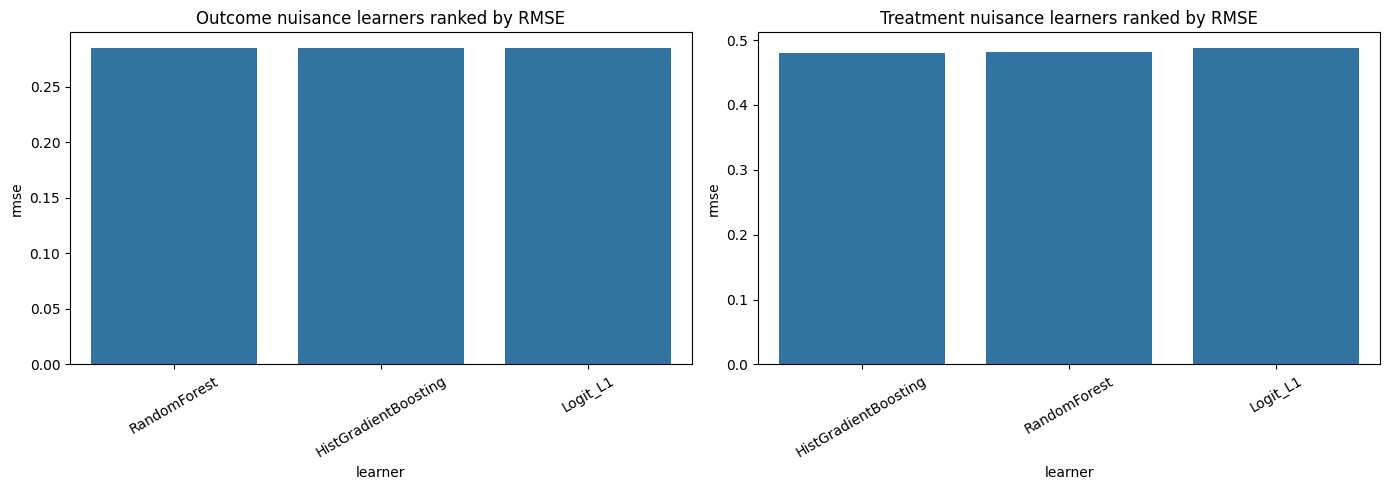

In [ ]:

score_plot_df = pd.concat([outcome_scores, treatment_scores], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

sns.barplot(
    data=outcome_scores.sort_values("rmse"),
    x="learner",
    y="rmse",
    ax=axes[0],
)
axes[0].set_title("Outcome nuisance learners ranked by RMSE")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=treatment_scores.sort_values("rmse"),
    x="learner",
    y="rmse",
    ax=axes[1],
)
axes[1].set_title("Treatment nuisance learners ranked by RMSE")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()



The ranking gaps are tiny. That is already a clue that the signal is not highly nonlinear or unstable.

We select the best-performing nuisance learner for each prediction task using the out-of-fold RMSE results.

From the stored search results, we extract the tuned best estimator for each winner
and clone it so we have a clean model object ready for later fitting and prediction.


In [13]:

best_outcome_name = outcome_scores.sort_values("rmse").iloc[0]["learner"]
best_treatment_name = treatment_scores.sort_values("rmse").iloc[0]["learner"]

best_outcome_learner = clone(outcome_searches[best_outcome_name].best_estimator_)
best_treatment_learner = clone(treatment_searches[best_treatment_name].best_estimator_)

print(f"Best learner for P(Y=1|X): {best_outcome_name}")
print(f"Best learner for P(D=1|X): {best_treatment_name}")


Best learner for P(Y=1|X): RandomForest
Best learner for P(D=1|X): HistGradientBoosting



### Random-forest variability across outer folds

This section addresses the practical question of whether a tree-based learner behaves stably across resamples. We examine how stable the tuned random forest treatment model is across outer CV folds. 

What it shows:
- the distribution of fold-level predictive scores for the tuned random forest,
- and the spread of feature importances across folds.

We run cross-validation on the RandomForest search object itself, so each fold includes inner-CV hyperparameter tuning followed by evaluation on the held-out outer fold. The resulting table and boxplots summarize how MSE (Brier score), ROC-AUC, and accuracy vary across folds, which helps assess whether performance is consistent or highly split-dependent.

We also extract feature importances from the best random forest in each fold and combine them into one long table for comparison. Averaging importances identifies the top predictors, while the boxplot shows how much their importance changes across folds.

This gives a stability check for both predictive performance and variable ranking.

,fold,brier,roc_auc,accuracy
0,1,0.232635,0.645985,0.602121
1,2,0.231212,0.651552,0.608878
2,3,0.232579,0.646572,0.605669


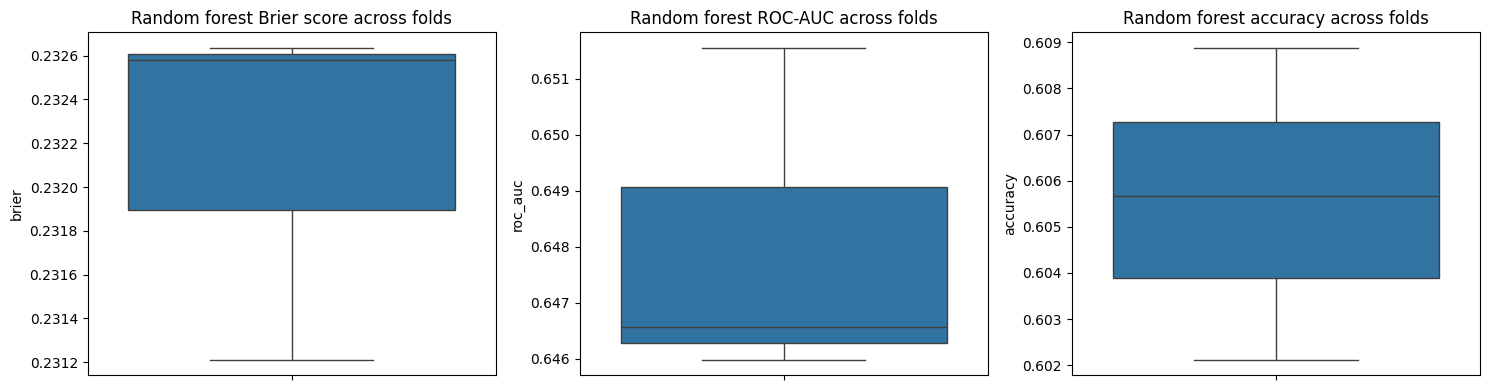

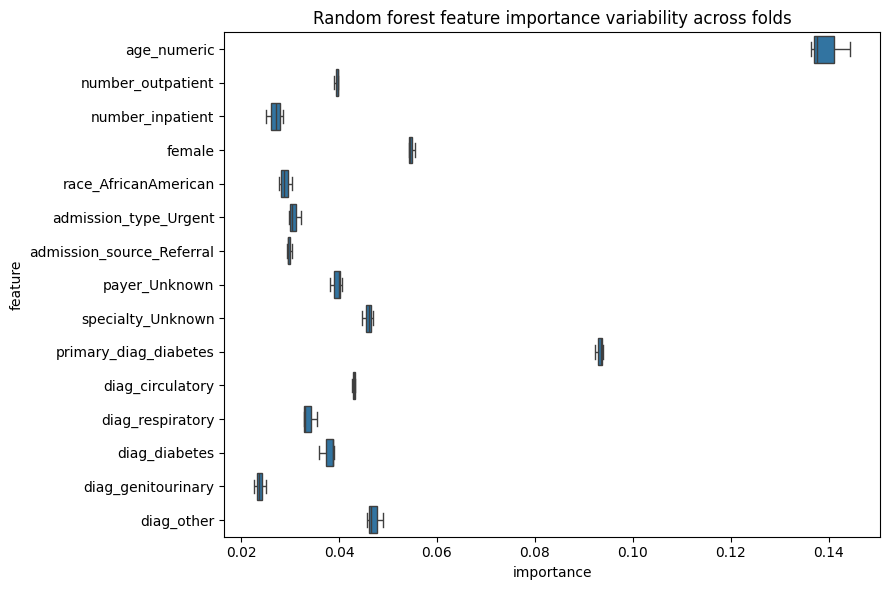

In [14]:

rf_search_template = make_search_objects()["RandomForest"]

rf_cv_result = cross_validate(
    estimator=rf_search_template,
    X=X,
    y=D,
    cv=outer_cv,
    scoring={
        "brier": "neg_brier_score",
        "roc_auc": "roc_auc",
        "accuracy": "accuracy",
    },
    return_estimator=True,
    n_jobs=-1,
)

rf_fold_metrics = pd.DataFrame({
    "fold": np.arange(1, cv_outer_folds + 1),
    "brier": -rf_cv_result["test_brier"],
    "roc_auc": rf_cv_result["test_roc_auc"],
    "accuracy": rf_cv_result["test_accuracy"],
})

display(rf_fold_metrics)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=rf_fold_metrics["brier"], ax=axes[0])
axes[0].set_title("Random forest Brier score across folds")

sns.boxplot(y=rf_fold_metrics["roc_auc"], ax=axes[1])
axes[1].set_title("Random forest ROC-AUC across folds")

sns.boxplot(y=rf_fold_metrics["accuracy"], ax=axes[2])
axes[2].set_title("Random forest accuracy across folds")
plt.tight_layout()

importance_rows = []
for fold_id, est in enumerate(rf_cv_result["estimator"], start=1):
    best_pipe = est.best_estimator_
    feature_names = best_pipe.named_steps["preprocess"].get_feature_names_out()
    importances = best_pipe.named_steps["model"].feature_importances_
    importance_rows.append(pd.DataFrame({
        "fold": fold_id,
        "feature": feature_names,
        "importance": importances,
    }))

rf_importance_df = pd.concat(importance_rows, ignore_index=True)
top_rf_features = (
    rf_importance_df.groupby("feature")["importance"].mean()
    .sort_values(ascending=False)
    .head(15)
    .index
)

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=rf_importance_df[rf_importance_df["feature"].isin(top_rf_features)],
    y="feature",
    x="importance",
)
plt.title("Random forest feature importance variability across folds")
plt.tight_layout()



### Interpretation

The random forest nuisance learner performs very consistently across outer folds: the MSE (Brier) remains around 0.23, ROC-AUC is about 0.66, and accuracy is around 0.61. The low variations suggest that the learner’s predictive performance is stable across sample splits rather than being driven by one particularly favorable fold. This is reassuring because it indicates that the nuisance-model quality used in the DML procedure is robust. The variability of features across folds also looks stable.


### 2.2. Double Machine Learning estimation

We now move from predictive tuning to causal estimation.

### Estimators implemented
- **DML-PLR**: partially linear regression
- **DML-IRM**: interactive regression model

### Why we use both PLR and IRM?
- **PLR** is a useful partially linear benchmark.
- **IRM** is especially natural here because the treatment is binary and the estimator is built around treatment-specific outcome regressions and a propensity score.

Then, the final DML object is evaluated.


In [15]:

dml_data = DoubleMLData(
    analysis_df,
    y_col=outcome_var,
    d_cols=treatment_var,
    x_cols=X_columns,
)


We estimate the main causal effects with DoubleML using the best-performing nuisance learners from the tuning step. 

In DoubleML-PLR, the partially linear model is: $Y = \theta_0 D + g_0(X) + \epsilon,$ with $E[\epsilon | D, X] = 0$, and $D = m_0(X) + v$, with $E[v | X] = 0$.
The nuisance functions are: $\ell_0(X) = E[Y | X]$ and $m_0(X) = E[D | X]$.
We form the residuals: $\tilde{Y} = Y - \hat{\ell}(X)$ and $\tilde{D} = D - \hat{m}(X)$, and estimate $\theta_0$ from the orthogonal moment.

In DoubleML-IRM, treatment effects are allowed to vary across individuals. The model is:
$Y = g_0(D, X) + \epsilon$, with $E[\epsilon | D, X] = 0$, and $D = m_0(X) + \tilde{\epsilon}$, with $E[\tilde{\epsilon} | X] = 0$.
The nuisance functions are:
$m_0(X) = P(D = 1 | X)$, $g_1(X) = E[Y | D = 1, X]$ and $g_0(X) = E[Y | D = 0, X]$.
For IRM, the average treatment effect is:
$\mathrm{ATE} = E[g_1(X) - g_0(X)]$,
and the average treatment effect on the treated is:
$\mathrm{ATT} = E[g_1(X) - g_0(X) | D = 1]$.

We fit IRM for both the ATE and the ATT, under the identifying assumption $Y(0), Y(1) ⟂ D | X$.

We reuse the same best nuisance learner family for PLR and IRM because both estimators rely on the same basic objects: conditional expectations and conditional probabilities based on the same covariates $X$. The tuning step identifies which learner predicts these nuisance quantities best in our data, and we then carry that specification into the final DoubleML stage. 

In PLR this gives $\hat{\ell}(X)$ and $\hat{m}(X)$, while in IRM it gives $\hat{m}(X)$ together with the treated and untreated outcome regressions $\hat{g}_1(X)$ and $\hat{g}_0(X)$. 

The summary tables report the estimated causal effect together with its standard error, test statistic, $p$-value, and confidence interval.

In [16]:
dml_plr = dml.DoubleMLPLR(
    dml_data,
    ml_l=clone(best_outcome_learner),
    ml_m=clone(best_treatment_learner),
    n_folds=cv_outer_folds,
    n_rep=1,
)
dml_plr.fit()

dml_irm_ate = dml.DoubleMLIRM(
    dml_data,
    ml_g=clone(best_outcome_learner),
    ml_m=clone(best_treatment_learner),
    n_folds=cv_outer_folds,
    n_rep=1,
    score="ATE",
)
dml_irm_ate.fit()

dml_irm_atte = dml.DoubleMLIRM(
    dml_data,
    ml_g=clone(best_outcome_learner),
    ml_m=clone(best_treatment_learner),
    n_folds=cv_outer_folds,
    n_rep=1,
    score="ATTE",
)
dml_irm_atte.fit()

print("DML-PLR summary")
display(dml_plr.summary)

print("DML-IRM (ATE) summary")
display(dml_irm_ate.summary)

print("DML-IRM (ATT) summary")
display(dml_irm_atte.summary)


/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/doubleml/double_ml.py:983: UserWarning: Learner provided for ml_l is probably invalid: Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  [1, 13, 14, 15]),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  [0, 2, 3, 4, 5, 6, 7, 8, 9,
                                                   10, 11, 12, 16, 17, 18, 19,
                                                   20, 21, 22, 23, 24, 25, 26,
                               

/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


DML-PLR summary


,coef,std err,t,P>|t|,2.5 %,97.5 %
insulin_any,0.014781,0.002423,6.100421,1.057897e-09,0.010032,0.01953


DML-IRM (ATE) summary


,coef,std err,t,P>|t|,2.5 %,97.5 %
insulin_any,0.014489,0.002297,6.307314,2.839196e-10,0.009986,0.018991


DML-IRM (ATT) summary


,coef,std err,t,P>|t|,2.5 %,97.5 %
insulin_any,0.013384,0.002391,5.598186,2.166057e-08,0.008698,0.018069


### Interpretation 

The DML-PLR estimate implies that insulin treatment is associated with an increase in readmission probability of around 1.48 percentage points, and this effect is statistically significant. 

The DML-IRM ATE estimate is slightly smaller at about 1.45 pp. (and significant) and the ATT estimate is even smaller at 1.34 pp. (and significant). The estimated effect among treated patients differs from (but only a little) the average effect in the full sample. 

Taken together, these results suggest a modest but robust positive treatment effect, with the similarity between PLR, ATE, and ATT estimates adding more credibility to the main conclusion.


### **Final comparison table**

We puts all estimators in a common summary table:

- The **naive LPM** shows the raw association between insulin and readmission.
- The **adjusted LPM** adds the final control set linearly.
- **Double Post-Lasso** allows sparse control selection before the final regression.
- **DML-PLR** uses ML-based nuisance adjustment under a partially linear structure.
- **DML-IRM** is especially relevant with a binary treatment and gives our most policy-relevant causal benchmark.

The key empirical question is whether the estimated effect of insulin on 30-day readmission remains stable in sign and broadly similar in magnitude once we move from naive association to increasingly flexible adjustment.


In [17]:

def extract_dml_result(name, obj):
    est = float(obj.coef[0])
    se = float(obj.se[0])
    lo, hi = ci95(est, se)
    return {
        "estimator": name,
        "estimate": est,
        "std_error": se,
        "ci_low": lo,
        "ci_high": hi,
        "p_value": float(obj.pval[0]),
    }

rows = []

# Naive LPM
est = float(naive_lpm.params[treatment_var])
se = float(naive_lpm.bse[treatment_var])
lo, hi = ci95(est, se)
rows.append({
    "estimator": "Naive LPM: Y ~ D",
    "estimate": est,
    "std_error": se,
    "ci_low": lo,
    "ci_high": hi,
    "p_value": float(naive_lpm.pvalues[treatment_var]),
})

# Adjusted LPM
est = float(adjusted_lpm.params[treatment_var])
se = float(adjusted_lpm.bse[treatment_var])
lo, hi = ci95(est, se)
rows.append({
    "estimator": "Adjusted LPM: Y ~ D + X",
    "estimate": est,
    "std_error": se,
    "ci_low": lo,
    "ci_high": hi,
    "p_value": float(adjusted_lpm.pvalues[treatment_var]),
})

# Double Post-Lasso
est = float(double_post_lasso.params[treatment_var])
se = float(double_post_lasso.bse[treatment_var])
lo, hi = ci95(est, se)
rows.append({
    "estimator": "Double Post-Lasso",
    "estimate": est,
    "std_error": se,
    "ci_low": lo,
    "ci_high": hi,
    "p_value": float(double_post_lasso.pvalues[treatment_var]),
})

# DML objects
rows.append(extract_dml_result("DML-PLR", dml_plr))
rows.append(extract_dml_result("DML-IRM ATE", dml_irm_ate))
rows.append(extract_dml_result("DML-IRM ATT", dml_irm_atte))

final_comparison = pd.DataFrame(rows)
final_comparison = final_comparison.sort_values("estimate")

final_comparison


,estimator,estimate,std_error,ci_low,ci_high,p_value
5,DML-IRM ATT,0.013384,0.002391,0.008698,0.018069,2.166057e-08
0,Naive LPM: Y ~ D,0.013614,0.002204,0.009295,0.017932,6.490499e-10
4,DML-IRM ATE,0.014489,0.002297,0.009986,0.018991,2.839196e-10
2,Double Post-Lasso,0.014507,0.002256,0.010086,0.018929,1.270531e-10
1,Adjusted LPM: Y ~ D + X,0.014511,0.002258,0.010084,0.018937,1.318616e-10
3,DML-PLR,0.014781,0.002423,0.010032,0.019530,1.057897e-09


### Interpretation

The naive LPM (Y ~ D only) estimates that insulin-treated patients have a 1.36 percentage point higher probability of 30-day readmission. This is a raw association that captures both any causal effect of insulin and the fact that sicker patients are both more likely to receive insulin and more likely to be readmitted regardless. It cannot be given a causal interpretation.

Once controls are added, **the estimated effect becomes slightly bigger**, which is also the case for the adjusted LPM, Double Post-Lasso, DML-IRM and DML-PLR specifications, all lying in a narrow range of about 0.0136 to 0.0157. All effects are positive and significant. 

The stability across methods is reassuring: it suggests that the main finding (a positive association between insulin treatment and readmission risk) is not driven by one particular modeling approach.

_**Note:** The estimates that follow are the result of the most rigorous causal analysis possible given the available observational data. However, as established in the identification strategy in Notebook 3, the unconfoundedness assumption cannot be verified as unobserved physician judgment and bedside clinical assessment remain potential sources of bias that no estimator can eliminate from administrative data. We therefore interpret the DML estimates as the best available causal estimates but not as definitive proof of a causal effect, which may explain the limited differences in our exstimates._ 

We use a forest plot, which places all estimates on a common scale so we can compare both magnitude and statistical uncertainty across methods in one figure. Each point shows the estimated effect on 30-day readmission, and each horizontal bar shows the corresponding 95% confidence interval. The dashed vertical line marks zero effect.


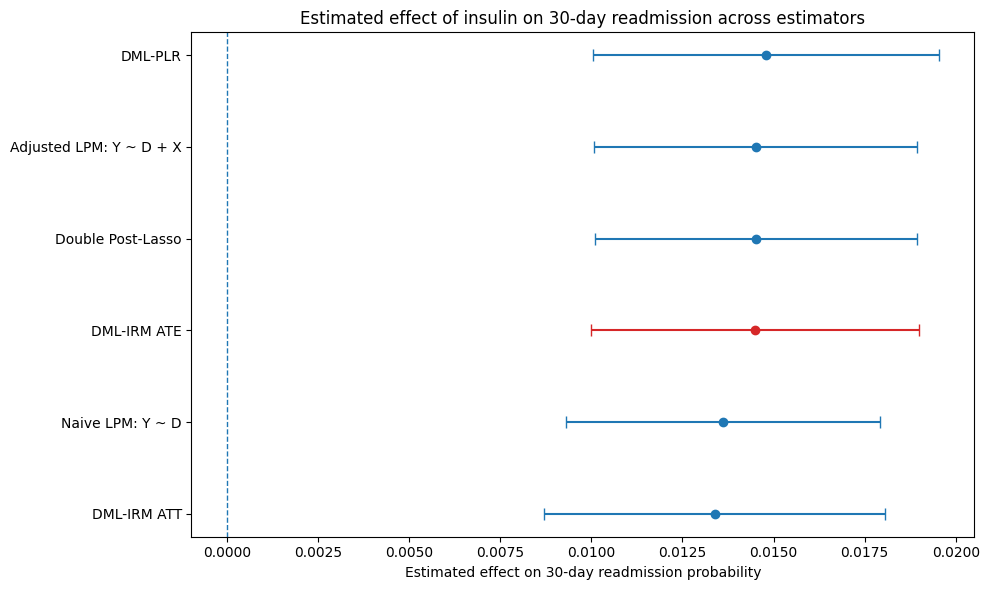

In [18]:

# Forest plot of treatment effect estimates and 95% confidence intervals

plot_df = final_comparison.copy()
plot_df["is_primary"] = plot_df["estimator"].eq("DML-IRM ATE")

fig, ax = plt.subplots(figsize=(10, 6))
y_positions = np.arange(len(plot_df))

for i, row in plot_df.reset_index(drop=True).iterrows():
    color = "tab:red" if row["is_primary"] else "tab:blue"
    ax.errorbar(
        x=row["estimate"],
        y=i,
        xerr=[[row["estimate"] - row["ci_low"]], [row["ci_high"] - row["estimate"]]],
        fmt="o",
        capsize=4,
        color=color,
    )

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df["estimator"])
ax.set_xlabel("Estimated effect on 30-day readmission probability")
ax.set_title("Estimated effect of insulin on 30-day readmission across estimators")
plt.tight_layout()


## Part 3 - Heterogeneity analysis

The full-sample **DML-IRM ATE** above remains our main estimate of choice.  

We now check whether the treatment effect looks different across a few **pre-specified subgroups** that follow directly from the research question and the earlier EDA/DAG work.

Our strategy is to estimate **subgroup-specific treatment effects** and compare them side by side, for the following groups: 

- age 65+, 
- prior inpatient visits, 
- weight observed, 
- gender,
- and primary diabetes diagnosis. 

This is related to the idea of a Conditional Average Treatment Effect (CATE), which is the treatment effect conditional on covariates X. However, rather than estimating a highly flexible person-specific or fully covariate-dependent CATE function, in this notebook, we ask whether the treatment effect differs across a small number of clinically meaningful groups. 

In that sense, these subgroup-specific effects are **CATE-style objects**: for a subgroup, we estimate the treatment effect **conditional on being in that subgroup**. Then, the result can be read as an average treatment effect **within that subgroup**, not for the whole population.

To keep the heterogeneity exercise tightly connected to the main notebook, we use the nuisance learners selected before the main DML stage.

This is deliberate. In a heterogeneity section, our main question is whether the *estimated treatment effect* differs across groups, not whether a different predictive learner wins inside every subgroup.


In [19]:
# we first construct subgroup indicators in analysis_df
analysis_df = analysis_df.copy()

analysis_df["age_65_plus"] = (analysis_df["age_numeric"] >= 65).astype(int)
analysis_df["any_prior_inpatient"] = (analysis_df["number_inpatient"] > 0).astype(int)

# we then define heterogeneity subgroup variables
heterogeneity_groups = {
    "Age 65+": "age_65_plus",
    "Any prior inpatient visit": "any_prior_inpatient",
    "Weight observed": "weight_observed",
    "Primary diagnosis = diabetes": "primary_diag_diabetes",
    "Female": "female",
}

# subgroup sizes
heterogeneity_counts = []
n_total = len(analysis_df)

for label, var in heterogeneity_groups.items():
    if var not in analysis_df.columns:
        raise KeyError(f"{var} is not in analysis_df")

    counts = analysis_df[var].value_counts(dropna=False).sort_index()

    for group_value, n_obs in counts.items():
        heterogeneity_counts.append({
            "subgroup": label,
            "group_value": group_value if pd.isna(group_value) else int(group_value),
            "n_obs": int(n_obs),
            "share": float(n_obs / n_total),
        })

heterogeneity_counts_df = pd.DataFrame(heterogeneity_counts)
heterogeneity_counts_df

,subgroup,group_value,n_obs,share
0,Age 65+,0,22780,0.338409
1,Age 65+,1,44535,0.661591
2,Any prior inpatient visit,0,58804,0.873565
3,Any prior inpatient visit,1,8511,0.126435
4,Weight observed,0,64551,0.958939
5,Weight observed,1,2764,0.041061
6,Primary diagnosis = diabetes,0,61771,0.917641
7,Primary diagnosis = diabetes,1,5544,0.082359
8,Female,0,31458,0.467325
9,Female,1,35857,0.532675


It is worth to note here that in case of weight observed and in case of primary dagnosis being diabetes the number of observations are not very high, but we belive they are still big enough for significant results.

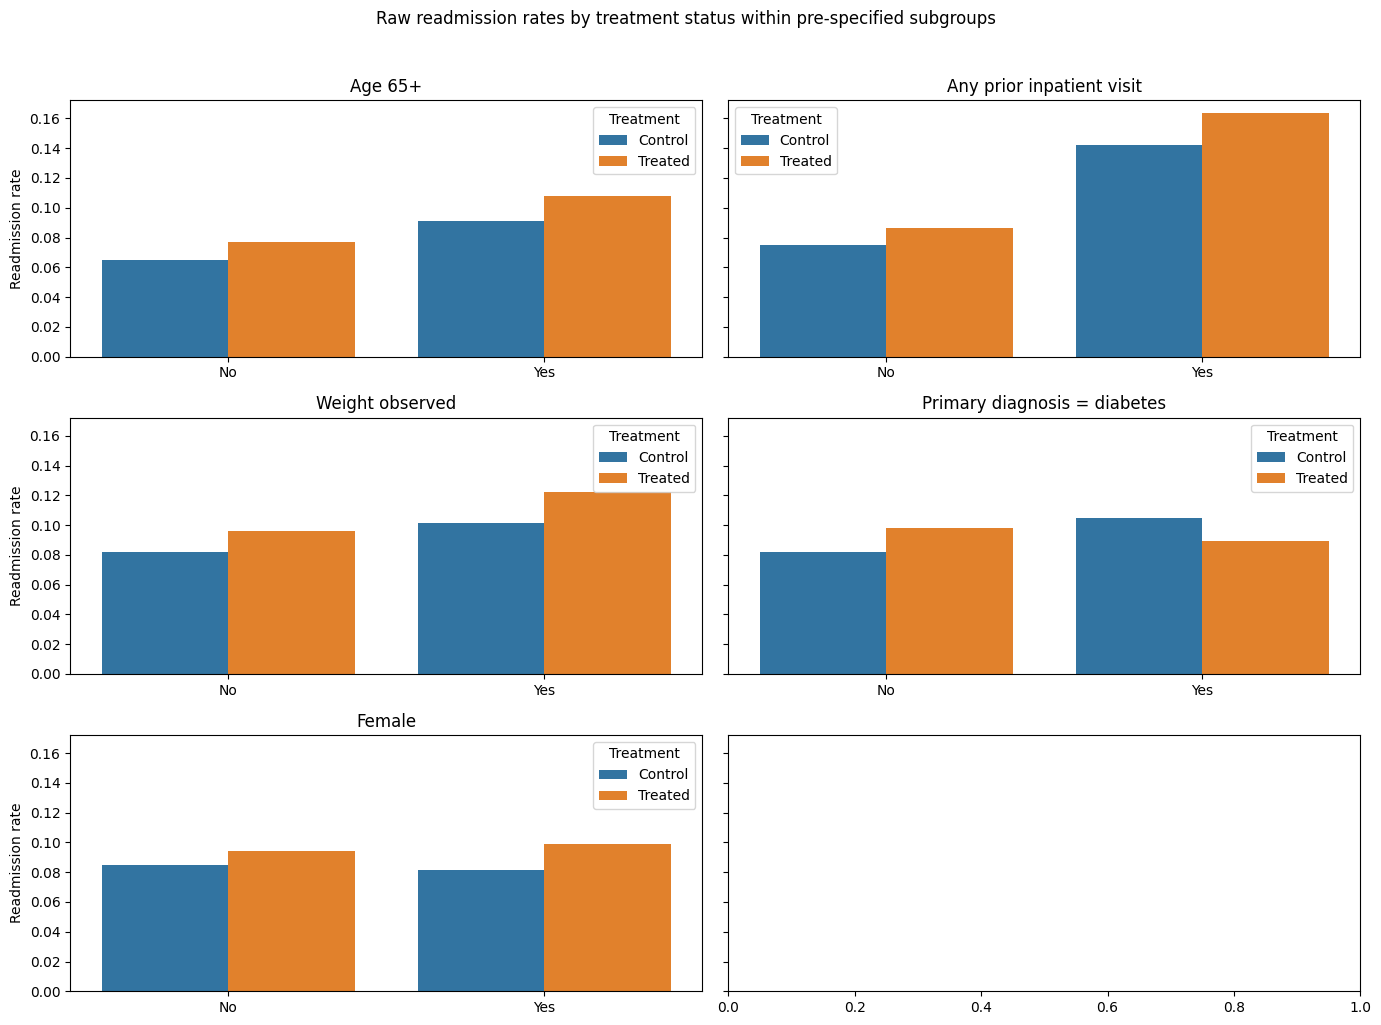

In [20]:
# raw readmission rates by treatment status within each subgroup
plot_rows = []
for label, var in heterogeneity_groups.items():
    grouped = (
        analysis_df
        .groupby([var, treatment_var])[outcome_var]
        .agg(["mean", "size"])
        .reset_index()
        .rename(columns={"mean": "readmission_rate", "size": "n_obs"})
    )
    grouped["subgroup"] = label
    plot_rows.append(grouped)

heterogeneity_plot_df = pd.concat(plot_rows, ignore_index=True)

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for ax, (label, var) in zip(axes, heterogeneity_groups.items()):
    tmp = heterogeneity_plot_df[heterogeneity_plot_df["subgroup"] == label].copy()
    tmp["group_label"] = tmp[var].map({0: "No", 1: "Yes"})
    tmp["treatment_label"] = tmp[treatment_var].map({0: "Control", 1: "Treated"})
    sns.barplot(
        data=tmp,
        x="group_label",
        y="readmission_rate",
        hue="treatment_label",
        ax=ax,
    )
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("Readmission rate")
    ax.legend(title="Treatment")

plt.suptitle("Raw readmission rates by treatment status within pre-specified subgroups", y=1.02)
plt.tight_layout()
plt.show()


The plot above summarizes substantial differences, which were highlighted more in the EDA notebook. It is clear that there are differences between these designated groups in the readmission rates.

In [21]:
# subgroup-specific DML-IRM estimates
heterogeneity_results = []

base_excluded = {
    outcome_var,
    treatment_var,
    "treatment_multivalued",
    "insulin_up_only",
    "insulin_steady_only",
}

for label, var in heterogeneity_groups.items():
    for group_value in [0, 1]:

        # restrict rows first
        subgroup_mask = analysis_df[var] == group_value
        subgroup_n = int(subgroup_mask.sum())

        if subgroup_n == 0:
            continue

        # keep main X-space, but drop anything excluded
        x_cols_sub = [c for c in X_columns if c not in base_excluded]

        # build subgroup dataset
        subgroup_df = analysis_df.loc[
            subgroup_mask,
            [outcome_var, treatment_var] + x_cols_sub
        ].copy()

        dml_sub_data = DoubleMLData(
            subgroup_df,
            y_col=outcome_var,
            d_cols=treatment_var,
            x_cols=x_cols_sub,
        )

        dml_sub_irm = dml.DoubleMLIRM(
            dml_sub_data,
            ml_g=clone(best_outcome_learner),
            ml_m=clone(best_treatment_learner),
            n_folds=cv_outer_folds,
            n_rep=1,
            score="ATE",
        )
        dml_sub_irm.fit()

        est = float(dml_sub_irm.coef[0])
        se = float(dml_sub_irm.se[0])
        lo, hi = ci95(est, se)

        heterogeneity_results.append({
            "subgroup": label,
            "group_value": group_value,
            "group": "Yes" if group_value == 1 else "No",
            "n_obs": subgroup_n,
            "estimate": est,
            "std_error": se,
            "ci_low": lo,
            "ci_high": hi,
            "p_value": float(dml_sub_irm.pval[0]),
        })

heterogeneity_results_df = pd.DataFrame(heterogeneity_results)
heterogeneity_results_df

/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' wa

,subgroup,group_value,group,n_obs,estimate,std_error,ci_low,ci_high,p_value
0,Age 65+,0,No,22780,0.010887,0.003705,0.003625,0.018150,3.300638e-03
1,Age 65+,1,Yes,44535,0.016727,0.002947,0.010951,0.022503,1.376218e-08
2,Any prior inpatient visit,0,No,58804,0.014373,0.002356,0.009755,0.018990,1.054839e-09
3,Any prior inpatient visit,1,Yes,8511,0.017599,0.009129,-0.000293,0.035492,5.387075e-02
4,Weight observed,0,No,64551,0.015070,0.002349,0.010465,0.019675,1.413005e-10
5,Weight observed,1,Yes,2764,0.010549,0.019301,-0.027280,0.048378,5.846663e-01
6,Primary diagnosis = diabetes,0,No,61771,0.016600,0.002384,0.011927,0.021272,3.332488e-12
7,Primary diagnosis = diabetes,1,Yes,5544,-0.003769,0.012640,-0.028543,0.021006,7.655871e-01
8,Female,0,No,31458,0.011213,0.003323,0.004699,0.017727,7.406204e-04
9,Female,1,Yes,35857,0.017621,0.003222,0.011306,0.023936,4.525257e-08


### Interpretation
The estimated treatment effect is positive and statistically significant for most subgroups.

For patients aged 65+, the effect is bigger (0.017) as compared to those under 65 (0.011), which suggests somewhat stronger effects among older patients. 

For patients with no prior inpatient visit, the effect is smaller (0.014) than for those with prior inpatient visits (0.018), which again underlines the importance/influence of this variable in our analysis.

For patients who had their weight recorded, the effect is actually smaller (but infisnificant) (0.011) as compared to the patients who did not have their weight recorded (0.015). Since we consider this as out monitoring intensity proxy, this difference may imply that higher monitoring actually leads to less chance of readmission. However, it is important to note that the patients who has the weight observed form a small group in the population and this is not a fully precise proxy either.

For those without a primary diabetes diagnosis, the effect is around 1.66 pp. as compared to those with the diagnosis who have a negative (but insignificant) effect (-0.004). This could be explained by hypothesising that patients with a known diabetes condition receive a treatment that is more tailored to them and so they are not as likely to be re-admitted.

Finally, for women, the treatment effect is bigger (0.018) as comapred to men (0.011).

Overall, the estimates suggest heterogeneity in magnitude (and in direction in one case of primary diagnosis being diabetes). In general, the effect is well-identified, consistently positive and significant. The variation in magnitude across subgroups is suggestive but should be interpreted cautiously, as we do not formally test equality across groups.

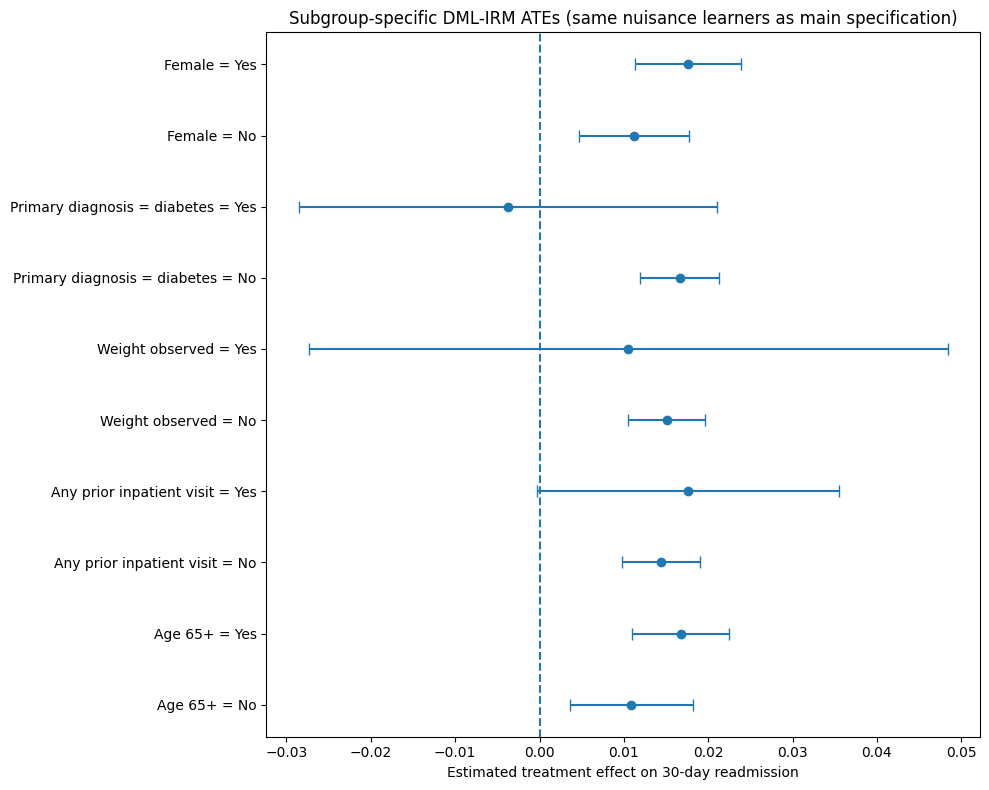

In [22]:
# Forest-style visualization of subgroup-specific DML-IRM effects
plot_df = heterogeneity_results_df.copy()
plot_df["label"] = plot_df["subgroup"] + " = " + plot_df["group"]

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(plot_df))

ax.errorbar(
    x=plot_df["estimate"],
    y=y_pos,
    xerr=1.96 * plot_df["std_error"],
    fmt="o",
    capsize=4,
)

ax.axvline(0, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("Estimated treatment effect on 30-day readmission")
ax.set_title("Subgroup-specific DML-IRM ATEs (same nuisance learners as main specification)")
plt.tight_layout()
plt.show()


## Part 4 - Sensitivity analysis

The purpose of this section is to ask the following econometric question:

> **Does the conclusion remain similar when we perturb key modeling choices ?**

We focus on three targeted sensitivity checks:

1. **Different treatment definitions**  
   We compare the main insulin treatment with alternative binary definitions and with metformin as a treatment.

2. **Different covariate sets**  
   We also verify whether the main DML-IRM estimate is sensitive to using a bigger control set.

3. **Placebo check**  
   We randomly permute treatment assignment and verify that the estimated effect collapses toward zero.

### In some cases, we decided to re-run full nuisance selection

For the main specification, nuisance selection was done carefully in the earlier sections of this notebook. In the sensitivity analysis, the goal is to vary the causal specification while keeping the nuisance-learning machinery as stable as possible. We follow this for the different insulin treatments definitions. 

Then, we re-run the treatment nuisance learner for the metformin extension (as the treatment definition changes substantially).

Finally, we also get 2 new learers (both for treatment and outcome) when we use an extended X dataset.


### 4.1 Dfferent treatment definitions (estimated with DML-IRM).


In [23]:

treatment_sensitivity_vars = {
    "Any insulin (main)": "insulin_any",
    "Steady insulin only": "insulin_steady_only",
    "Insulin dose increased": "insulin_up_only",
}

treatment_sensitivity_results = []

for label, treat_var in treatment_sensitivity_vars.items():

    dml_alt_data = DoubleMLData(
        analysis_df,
        y_col=outcome_var,
        d_cols=treat_var,
        x_cols=X_columns,
    )

    dml_alt_irm = dml.DoubleMLIRM(
        dml_alt_data,
        ml_g=clone(best_outcome_learner),
        ml_m=clone(best_treatment_learner),
        n_folds=cv_outer_folds,
        n_rep=1,
        score="ATE",
    )
    dml_alt_irm.fit()

    est = float(dml_alt_irm.coef[0])
    se = float(dml_alt_irm.se[0])
    lo, hi = ci95(est, se)

    treatment_sensitivity_results.append({
        "treatment_definition": label,
        "estimate": est,
        "std_error": se,
        "ci_low": lo,
        "ci_high": hi,
        "p_value": float(dml_alt_irm.pval[0]),
    })

treatment_sensitivity_df = pd.DataFrame(treatment_sensitivity_results)
treatment_sensitivity_df


/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' wa

,treatment_definition,estimate,std_error,ci_low,ci_high,p_value
0,Any insulin (main),0.014354,0.002322,0.009804,0.018905,6.296342e-10
1,Steady insulin only,0.002726,0.002418,-0.002012,0.007465,2.594518e-01
2,Insulin dose increased,0.013865,0.004871,0.004318,0.023412,4.419925e-03


### Interpretation

The estimated effect is positive and statistically significant for all the insulin treatment definitions.

For the main definition (any insulin), the estimate is around 0.014. It just is slightly different to our first ATE results due to random sampling in the DML (which we could also fix to be more precise, but we leave it be as this section has a comparative character).

When insulin is defined more narrowly, the effect for **steady insulin only** is way smaller (0.003), whereas for **insulin dose increased** we have a comparable average treatment effect of around 0.014 again, suggesting that the increase in readmission risk is more closely tied to treatment intensification than to steady insulin use. 

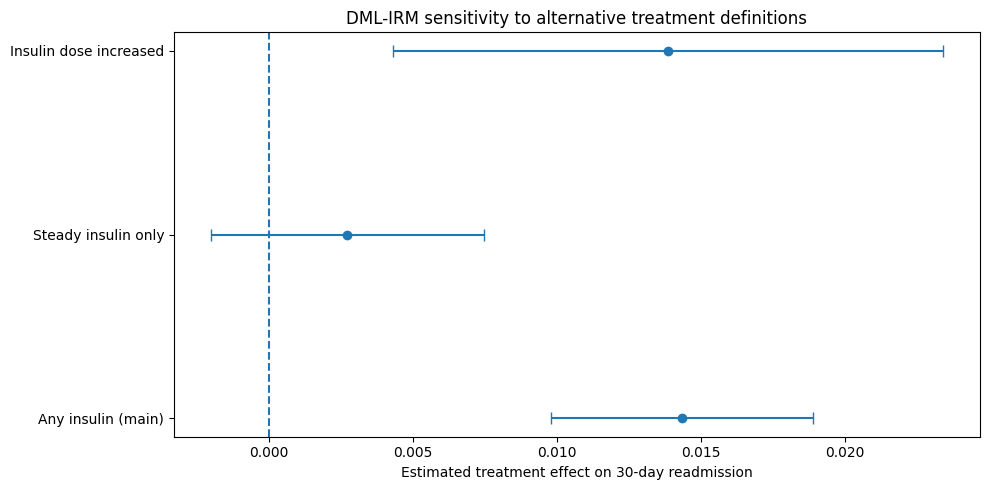

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(treatment_sensitivity_df))

ax.errorbar(
    x=treatment_sensitivity_df["estimate"],
    y=y_pos,
    xerr=1.96 * treatment_sensitivity_df["std_error"],
    fmt="o",
    capsize=4,
)
ax.axvline(0, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(treatment_sensitivity_df["treatment_definition"])
ax.set_xlabel("Estimated treatment effect on 30-day readmission")
ax.set_title("DML-IRM sensitivity to alternative treatment definitions")
plt.tight_layout()
plt.show()


### Metformin check - extension

When doimg the EDA, we found that the most popular medication apart from insulin is Metformin, which is why we wanted to see how it would behave as a treatment variable.

We tune the nuisance treatment paarmeter again in this section for metformin. We also keep the same X-space as in the main specification. Since outcome is unchanged, we reuse the best learner for outcome.



In [25]:

met_treat_var = "metformin_binary"

# we build a new estimation sample with same Y and X and new treatment
metformin_df = analysis_df[[outcome_var, met_treat_var] + X_columns].copy()

Y_met = metformin_df[outcome_var].astype(int)
D_met = metformin_df[met_treat_var].astype(int)
X_met = metformin_df[X_columns]

# we reselect ONLY the treatment-side nuisance learner: P(D_met=1 | X)

met_treatment_scores, met_treatment_fold_scores, met_treatment_searches, met_treatment_oof = (
    evaluate_probability_learners(
        X_met,
        D_met,
        task_name=f"Treatment nuisance: P({met_treat_var}=1|X)"
    )
)

print("Metformin treatment learner ranking:")
display(met_treatment_scores)

best_met_treatment_name = met_treatment_scores.sort_values("rmse").iloc[0]["learner"]
best_met_treatment_learner = clone(
    met_treatment_searches[best_met_treatment_name].best_estimator_
)

print(f"Reused learner for P(Y=1|X): {best_outcome_name}")
print(f"Best learner for P({met_treat_var}=1|X): {best_met_treatment_name}")

# after selection, we fit DML-IRM with reused outcome learner and new treatment learner

dml_met_data = DoubleMLData(
    metformin_df[[outcome_var, met_treat_var] + X_columns],
    y_col=outcome_var,
    d_cols=met_treat_var,
    x_cols=X_columns,
)

dml_met_irm = dml.DoubleMLIRM(
    dml_met_data,
    ml_g=clone(best_outcome_learner),  
    ml_m=clone(best_met_treatment_learner),
    n_folds=cv_outer_folds,
    n_rep=1,
    score="ATE",
)
dml_met_irm.fit()

print("DML-IRM (ATE) summary for metformin")
display(dml_met_irm.summary)


Metformin treatment learner ranking:


,task,learner,mse,rmse,log_loss,roc_auc,accuracy
2,Treatment nuisance: P(metformin_binary=1|X),HistGradientBoosting,0.160510,0.400637,0.496538,0.641182,0.787180
1,Treatment nuisance: P(metformin_binary=1|X),RandomForest,0.162334,0.402908,0.501976,0.625597,0.787001
0,Treatment nuisance: P(metformin_binary=1|X),Logit_L1,0.162903,0.403612,0.503851,0.614842,0.787358


Reused learner for P(Y=1|X): RandomForest
Best learner for P(metformin_binary=1|X): HistGradientBoosting


/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


DML-IRM (ATE) summary for metformin


,coef,std err,t,P>|t|,2.5 %,97.5 %
metformin_binary,-0.003797,0.002899,-1.309891,0.190233,-0.009478,0.001884


### Interpretation 

We define Metformin as the main treatment instead of insulin and we obtain that the ATE is negative (-0.004), but statistically insignificant. 


### 4.2 Alternative covariate sets for the main insulin_any treatment

In this section, we will have to once again run learner selection as our set of covariates X changes. Besides that, we follow the steps used (and explained) earlier for the insulin DML.

In [26]:

extended_sensitivity_vars = [
    # severity
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses",

    # laboratory/testing variables
    "A1C_tested",
    "A1C_abnormal",
    "glu_tested",
    "glu_abnormal",

    # treatment profile
    "any_non_insulin_meds"
]

required_cols = [outcome_var, treatment_var] + extended_sensitivity_vars + X_columns

extended_sensitivity_df = analysis_df[required_cols].copy()

Y_ext = extended_sensitivity_df[outcome_var].astype(int)
D_ext = extended_sensitivity_df[treatment_var].astype(int)
X_ext = extended_sensitivity_df[extended_sensitivity_vars+X_columns]

In [27]:

# we rebuild preprocessors for our new extended X-space

ext_binary_features = [
    c for c in extended_sensitivity_vars+X_columns
    if set(pd.Series(X_ext[c]).dropna().unique()).issubset({0, 1})
]

ext_numeric_features = [c for c in extended_sensitivity_vars+X_columns if c not in ext_binary_features]

ext_numeric_cols = [X_ext.columns.get_loc(col) for col in ext_numeric_features]
ext_binary_cols  = [X_ext.columns.get_loc(col) for col in ext_binary_features]

ext_linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            ext_numeric_cols,
        ),
        (
            "bin",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
            ]),
            ext_binary_cols,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

ext_tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            ext_numeric_cols,
        ),
        (
            "bin",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
            ]),
            ext_binary_cols,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)


In [28]:

# now, we do nuisance learner selection -> for this X-space so using different preprocessors

def make_search_objects_extended():
    return {
        "Logit_L1": GridSearchCV(
            estimator=Pipeline([
                ("preprocess", clone(ext_linear_preprocessor)),
                ("model", LogisticRegression(
                    penalty="l1",
                    solver="saga",
                    max_iter=1000,
                    random_state=seed,
                )),
            ]),
            param_grid={
                "model__C": [0.1, 1.0],
            },
            scoring="neg_brier_score",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
        ),
        "RandomForest": RandomizedSearchCV(
            estimator=Pipeline([
                ("preprocess", clone(ext_tree_preprocessor)),
                ("model", RandomForestClassifier(
                    random_state=seed,
                    n_jobs=-1,
                )),
            ]),
            param_distributions={
                "model__n_estimators": [100, 300],
                "model__max_depth": [5, None],
                "model__min_samples_leaf": [1, 10],
                "model__max_features": ["sqrt", 0.5],
            },
            n_iter=search_iterations,
            scoring="neg_brier_score",
            cv=inner_cv,
            n_jobs=-1,
            random_state=seed,
            refit=True,
        ),
        "HistGradientBoosting": RandomizedSearchCV(
            estimator=Pipeline([
                ("preprocess", clone(ext_tree_preprocessor)),
                ("model", HistGradientBoostingClassifier(
                    random_state=seed,
                )),
            ]),
            param_distributions={
                "model__learning_rate": [0.05, 0.1],
                "model__max_iter": [100, 200],
                "model__max_depth": [3, None],
                "model__min_samples_leaf": [50, 100],
                "model__l2_regularization": [0.0, 0.1],
            },
            n_iter=search_iterations,
            scoring="neg_brier_score",
            cv=inner_cv,
            n_jobs=-1,
            random_state=seed,
            refit=True,
        ),
    }

def evaluate_probability_learners_extended(X, y, task_name):
    all_rows = []
    fold_rows = []
    oof_pred = {}
    fitted_searches = {}

    for learner_name, search_template in make_search_objects_extended().items():
        oof = pd.Series(index=y.index, dtype=float)

        for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            search = clone(search_template)
            search.fit(X_train, y_train)

            prob = search.best_estimator_.predict_proba(X_test)[:, 1]
            pred = (prob >= 0.5).astype(int)
            oof.iloc[test_idx] = prob

            fold_rows.append({
                "task": task_name,
                "learner": learner_name,
                "fold": fold_id,
                "mse": mean_squared_error(y_test, prob),
                "rmse": np.sqrt(mean_squared_error(y_test, prob)),
                "log_loss": log_loss(y_test, prob, labels=[0, 1]),
                "roc_auc": roc_auc_score(y_test, prob),
                "accuracy": accuracy_score(y_test, pred),
            })

        fitted_full = clone(search_template)
        fitted_full.fit(X, y)
        fitted_searches[learner_name] = fitted_full
        oof_pred[learner_name] = oof

        all_rows.append({
            "task": task_name,
            "learner": learner_name,
            "mse": mean_squared_error(y, oof),
            "rmse": np.sqrt(mean_squared_error(y, oof)),
            "log_loss": log_loss(y, oof, labels=[0, 1]),
            "roc_auc": roc_auc_score(y, oof),
            "accuracy": accuracy_score(y, (oof >= 0.5).astype(int)),
        })

    return (
        pd.DataFrame(all_rows).sort_values(["task", "mse"]),
        pd.DataFrame(fold_rows),
        fitted_searches,
        oof_pred,
    )


In [29]:

# here, we re-run nuisance learner selection on the new X

ext_outcome_scores, ext_outcome_fold_scores, ext_outcome_searches, ext_outcome_oof = (
    evaluate_probability_learners_extended(
        X_ext, Y_ext, task_name="Outcome nuisance: P(Y=1|X_ext)"
    )
)

ext_treatment_scores, ext_treatment_fold_scores, ext_treatment_searches, ext_treatment_oof = (
    evaluate_probability_learners_extended(
        X_ext, D_ext, task_name=f"Treatment nuisance: P({treatment_var}=1|X_ext)"
    )
)

print("Extended-spec outcome learner ranking:")
display(ext_outcome_scores)

print("Extended-spec treatment learner ranking:")
display(ext_treatment_scores)

best_ext_outcome_name = ext_outcome_scores.sort_values("rmse").iloc[0]["learner"]
best_ext_treatment_name = ext_treatment_scores.sort_values("rmse").iloc[0]["learner"]

best_ext_outcome_learner = clone(ext_outcome_searches[best_ext_outcome_name].best_estimator_)
best_ext_treatment_learner = clone(ext_treatment_searches[best_ext_treatment_name].best_estimator_)

print(f"Best learner for P(Y=1|X_ext): {best_ext_outcome_name}")
print(f"Best learner for P({treatment_var}=1|X_ext): {best_ext_treatment_name}")


Extended-spec outcome learner ranking:


,task,learner,mse,rmse,log_loss,roc_auc,accuracy
2,Outcome nuisance: P(Y=1|X_ext),HistGradientBoosting,0.080865,0.284367,0.296257,0.611532,0.909708
1,Outcome nuisance: P(Y=1|X_ext),RandomForest,0.080868,0.284373,0.296479,0.608793,0.909768
0,Outcome nuisance: P(Y=1|X_ext),Logit_L1,0.080879,0.284392,0.296334,0.610417,0.909604


Extended-spec treatment learner ranking:


,task,learner,mse,rmse,log_loss,roc_auc,accuracy
2,Treatment nuisance: P(insulin_any=1|X_ext),HistGradientBoosting,0.205349,0.453155,0.595265,0.741434,0.673728
1,Treatment nuisance: P(insulin_any=1|X_ext),RandomForest,0.209569,0.457787,0.605465,0.730178,0.666241
0,Treatment nuisance: P(insulin_any=1|X_ext),Logit_L1,0.218493,0.467433,0.626091,0.702050,0.645963


Best learner for P(Y=1|X_ext): HistGradientBoosting
Best learner for P(insulin_any=1|X_ext): HistGradientBoosting


In [32]:
# and finally we fit the DML-IRM on extended sensitivity specification

big_dml_data = DoubleMLData(
    extended_sensitivity_df,
    y_col=outcome_var,
    d_cols=treatment_var,
    x_cols=extended_sensitivity_vars+X_columns,
)

big_dml_irm = dml.DoubleMLIRM(
    big_dml_data,
    ml_g=clone(best_ext_outcome_learner),
    ml_m=clone(best_ext_treatment_learner),
    n_folds=cv_outer_folds,
    n_rep=1,
    score="ATE",
)
big_dml_irm.fit()

print("Extended-spec DML-IRM summary")
display(big_dml_irm.summary)


/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Extended-spec DML-IRM summary


,coef,std err,t,P>|t|,2.5 %,97.5 %
insulin_any,0.007758,0.002473,3.137274,0.001705,0.002911,0.012605


In [34]:

# comparison with main specification

big_est = float(big_dml_irm.coef[0])
big_se = float(big_dml_irm.se[0])
big_lo, big_hi = ci95(big_est, big_se)

compare_df = pd.DataFrame([
    {
        "specification": "Main DML-IRM",
        "estimate": float(dml_irm_ate.coef[0]),
        "std_error": float(dml_irm_ate.se[0]),
        "ci_low": ci95(float(dml_irm_ate.coef[0]), float(dml_irm_ate.se[0]))[0],
        "ci_high": ci95(float(dml_irm_ate.coef[0]), float(dml_irm_ate.se[0]))[1],
        "p_value": float(dml_irm_ate.pval[0])
    },
    {
        "specification": "Extended sensitivity DML-IRM",
        "estimate": big_est,
        "std_error": big_se,
        "ci_low": big_lo,
        "ci_high": big_hi,
        "p_value": float(big_dml_irm.pval[0])
    },
])

compare_df

,specification,estimate,std_error,ci_low,ci_high,p_value
0,Main DML-IRM,0.014489,0.002297,0.009986,0.018991,2.839196e-10
1,Extended sensitivity DML-IRM,0.007758,0.002473,0.002911,0.012605,1.705266e-03


# Interpretation 

The estimated treatment effect remains positive and statistically significant when moving from the main DML-IRM specification to the extended covariate set, but its magnitude falls from about 1.45 percentage points to about 0.78 percentage points. The sign and significance are preserved, but the estimated effect is sensitive to how richly the control set is defined.

The extended covariate set absorbs additional confounding or risk heterogeneity that was still partly captured by the treatment effect in the baseline model, so the smaller estimate may be viewed as a more conservative adjusted effect, given that we have added variables whose timing we classified as "ambiguous" in the DAG notebook.



### 4.3 Placebo check using a permuted treatment assignment



In [38]:
placebo_df = analysis_df[[outcome_var, treatment_var] + X_columns].copy()
placebo_df["placebo_treatment"] = analysis_df[treatment_var].sample(frac=1, random_state=seed).reset_index(drop=True)

dml_placebo_data = DoubleMLData(
    placebo_df,
    y_col=outcome_var,
    d_cols="placebo_treatment",
    x_cols=X_columns,
)

dml_placebo_irm = dml.DoubleMLIRM(
    dml_placebo_data,
    ml_g=clone(best_outcome_learner),
    ml_m=clone(best_treatment_learner),
    n_folds=cv_outer_folds,
    n_rep=1,
    score="ATE",
)
dml_placebo_irm.fit()

placebo_est = float(dml_placebo_irm.coef[0])
placebo_se = float(dml_placebo_irm.se[0])
placebo_lo, placebo_hi = ci95(placebo_est, placebo_se)

placebo_results_df = pd.DataFrame({
    "specification": ["Main DML-IRM", "Placebo DML-IRM (permuted treatment)"],
    "estimate": [float(dml_irm_ate.coef[0]), placebo_est],
    "std_error": [float(dml_irm_ate.se[0]), placebo_se],
    "ci_low": [ci95(float(dml_irm_ate.coef[0]), float(dml_irm_ate.se[0]))[0], placebo_lo],
    "ci_high": [ci95(float(dml_irm_ate.coef[0]), float(dml_irm_ate.se[0]))[1], placebo_hi],
    "p_value": [float(dml_irm_ate.pval[0]), float(dml_placebo_irm.pval[0])]
})
placebo_results_df


/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ja/anaconda3/envs/dml_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,specification,estimate,std_error,ci_low,ci_high,p_value
0,Main DML-IRM,0.014489,0.002297,0.009986,0.018991,2.839196e-10
1,Placebo DML-IRM (permuted treatment),0.001653,0.002197,-0.002654,0.005960,4.519219e-01


# Interpretation 

The main DML-IRM estimate is positive and statistically meaningful at about 1.4 percentage points, whereas the placebo specification, where treatment is randomly permuted-produce, has a much smaller estimate (0.0017) with a confidence interval that includes zero. We have statistical significance of both findings.

This is reassuring because it suggests that the main result is not simply being generated mechanically by the estimator or by chance correlations in the data. When the link between treatment and patient characteristics is deliberately broken, the estimated effect largely disappears, which supports the credibility of the baseline finding.


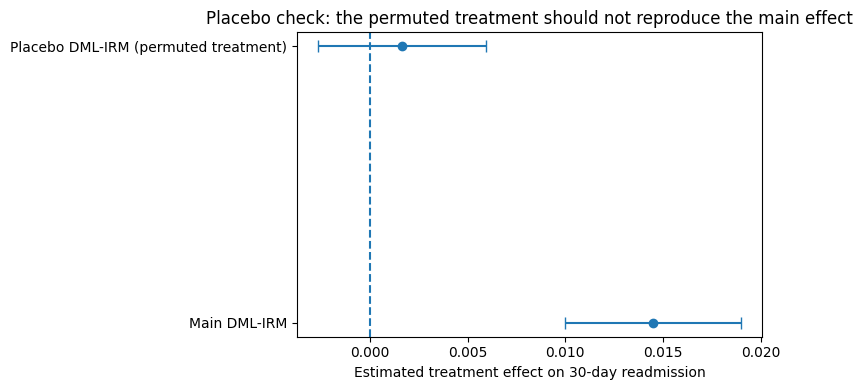

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))
y_pos = np.arange(len(placebo_results_df))

ax.errorbar(
    x=placebo_results_df["estimate"],
    y=y_pos,
    xerr=1.96 * placebo_results_df["std_error"],
    fmt="o",
    capsize=4,
)
ax.axvline(0, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(placebo_results_df["specification"])
ax.set_xlabel("Estimated treatment effect on 30-day readmission")
ax.set_title("Placebo check: the permuted treatment should not reproduce the main effect")
plt.tight_layout()
plt.show()


## Part 5 - Conclusion


Overall, the results point to a small but consistently positive estimated effect of in-hospital insulin prescription on 30-day readmission. 

In the main Double Machine Learning (IRM) specification, receiving any insulin is associated with an increase of about 1.45 percentage points in the probability of readmission within 30 days. This estimate is closely aligned with the simpler benchmark models, including the naive and adjusted linear probability models as well as the Double Post-Lasso specification. They all suggest a positive association of roughly similar magnitude. These results indicate that the finding is not driven by a single modeling choice.

In the heterogeneity section, the estimated effect remains positive for most subgroups and appears somewhat larger for older patients, for women, and for patients with prior inpatient hospital visits, suggesting that the relationship may be stronger among clinically more complex individuals. In the sensitivity checks, the main result remains positive when alternative treatment definitions and covariate set are considered, although its magnitude falls to about 0.78 percentage points in the extended X-set specification. This suggests that part of the estimated effect may be sensitive to how much patient severity and clinical context are controlled for. At the same time, the placebo analysis produces an estimate close to zero, which supports the idea that the main result is capturing a real signal rather than pure modeling noise.

Nevertheless, results should still be interpreted cautiously and not as definitive proof of a causal harmful effect of insulin itself. The credibility of the estimates depends on the assumption that the relevant confounders are adequately measured and included. In practice, treatment assignment is likely influenced by factors that are only imperfectly observed in the data, such as severity at the bedside, physician intuition, clinical judgment, concern about short-term glycemic instability, etc. that are essentially unobserved by us. Therefore, this residual confounding likely biases the estimated treatment effect upward. For that reason, the most defensible interpretation is that insulin prescription acts as a possible indicator for higher subsequent readmission risk, even after rich adjustment, rather than conclusive evidence that insulin directly increases readmission.

Overall, the main empirical takeaway is that patients receiving insulin appear to face a modestly higher adjusted probability of 30-day readmission, but the exact magnitude and causal interpretation remain uncertain because of potential unobserved confounding and clinician-driven treatment selection. Future work could strengthen the analysis through accounting better for unobserved confounding by designing a better dataset.